In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.svm import SVC
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

#Creating of Linear dataset

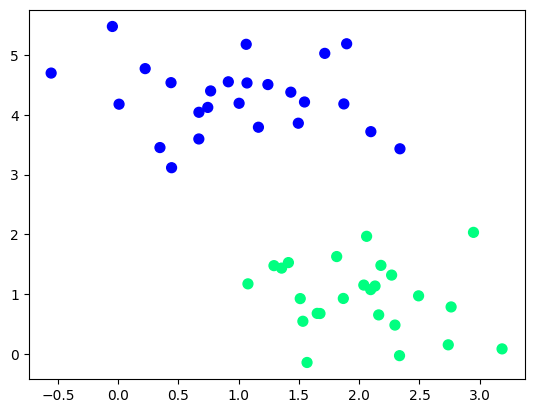

In [25]:
from sklearn.datasets import make_blobs
x, y = make_blobs(n_samples=50, centers = 2, random_state=0, cluster_std=0.60)
plt.scatter(x[:,0], x[:,1], c=y, s=50, cmap='winter')

In [26]:
model = SVC(kernel = 'linear', C=1)
model.fit(x,y)

SVC(C=1, kernel='linear')

In [27]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

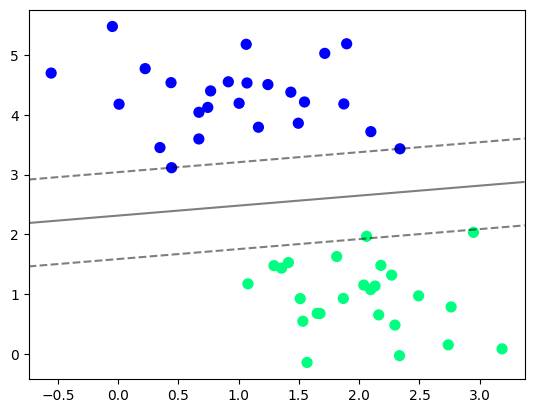

In [28]:
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

#Experiment of different number of datapoints

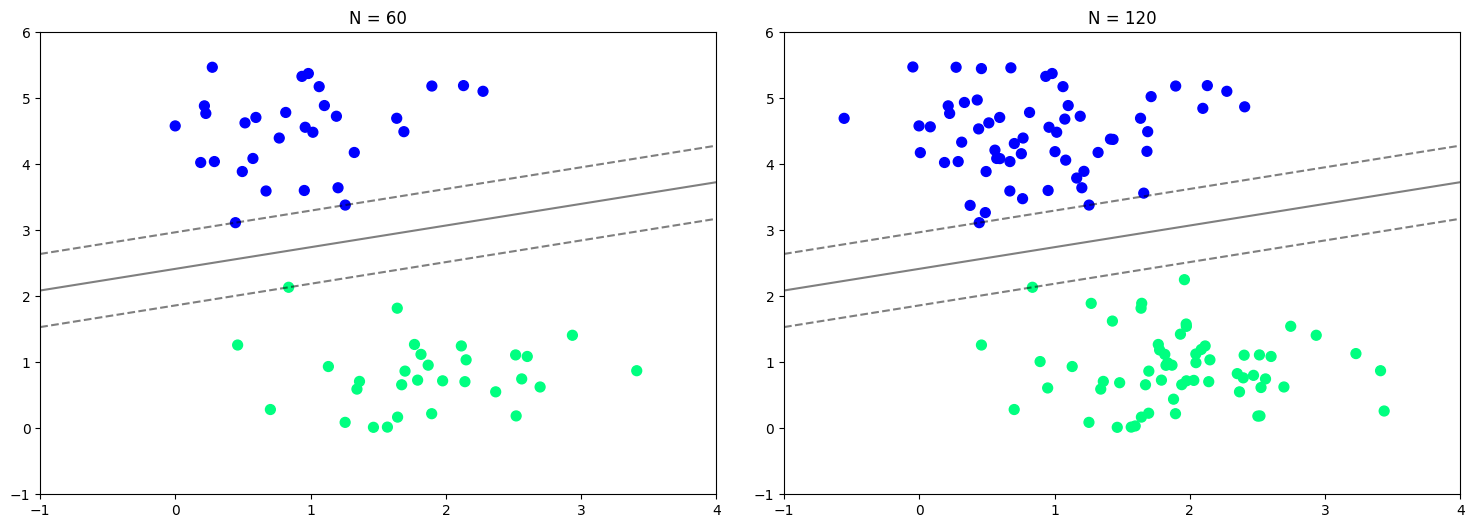

In [29]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

If we increase the points in both side, the decision line doesn't change, the decision line only depends only support vector points, not the number of points

#Creating a dataset that is not perfectly seperable

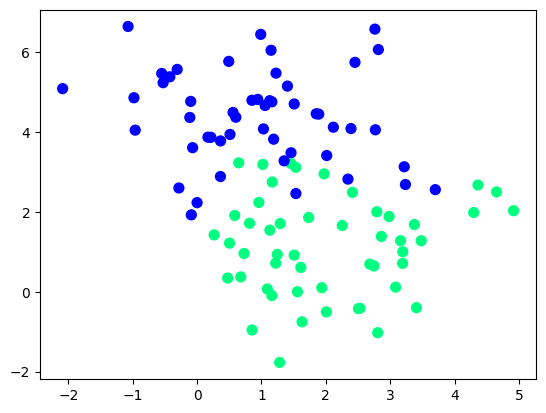

In [30]:
x, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, cmap='winter');

#For different C value

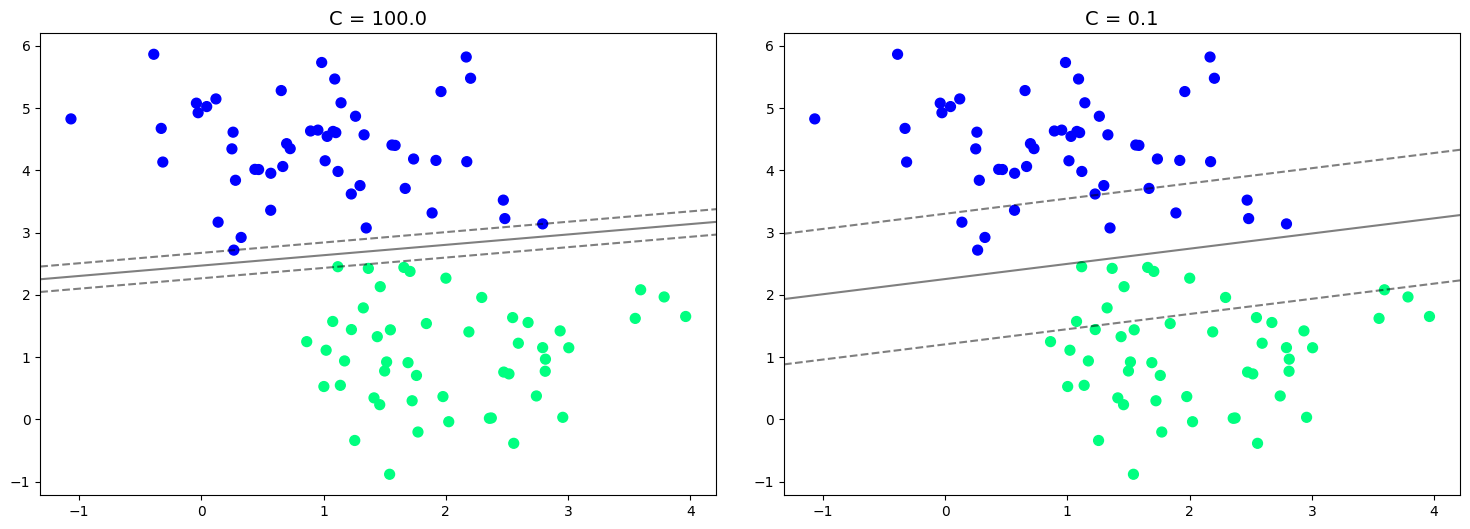

In [31]:

X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

#Using kernel trick method

#Creating dataset in 2D

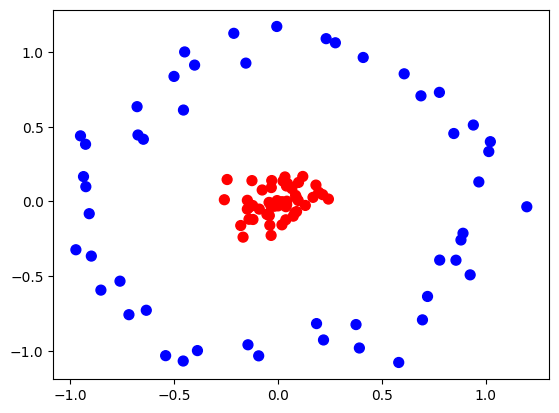

In [32]:
from sklearn.datasets import make_circles
x, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(x[:, 0], x[:, 1], c=y, s=50, cmap='bwr')

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [34]:
classifier = SVC(kernel = 'linear')
classifier.fit(x_train, y_train.ravel())
y_pred = classifier.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5

Linear kernel gives bad accuracy, now we use different kernel trick like rbf, polynomial, sigmoid

In [36]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_4774/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


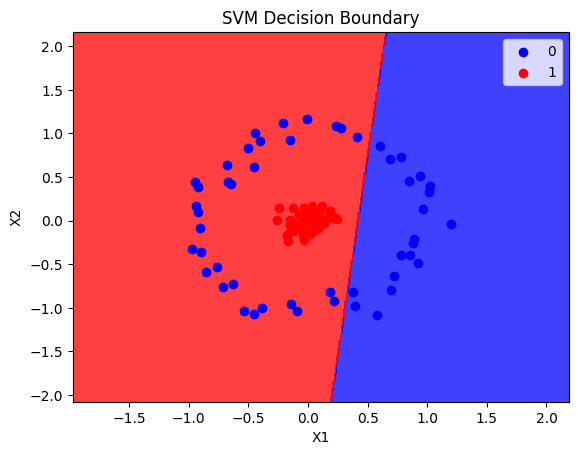

In [37]:
plot_decision_boundary(x, y, classifier)

In [38]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

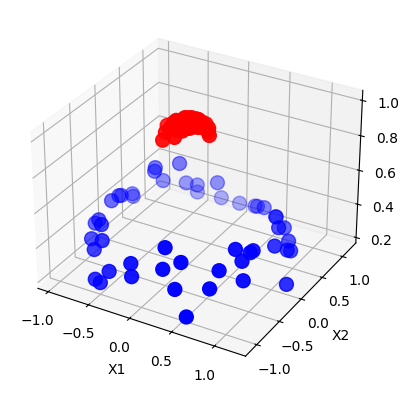

In [40]:
plot_3d_plot(x,y)

In [43]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(x_train, y_train)
y_pred = rbf_classifier.predict(x_test)

In [44]:
accuracy_score(y_test, y_pred)

1.0

After using rbf kernel method we are getting accuracy 100%

/tmp/ipykernel_4774/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


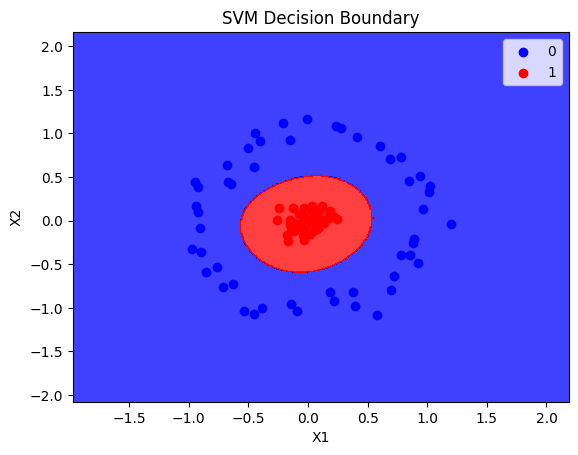

In [45]:
plot_decision_boundary(x, y, rbf_classifier)

In [46]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(x_train, y_train)
y_pred = poly_classifier.predict(x_test)

In [47]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_4774/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


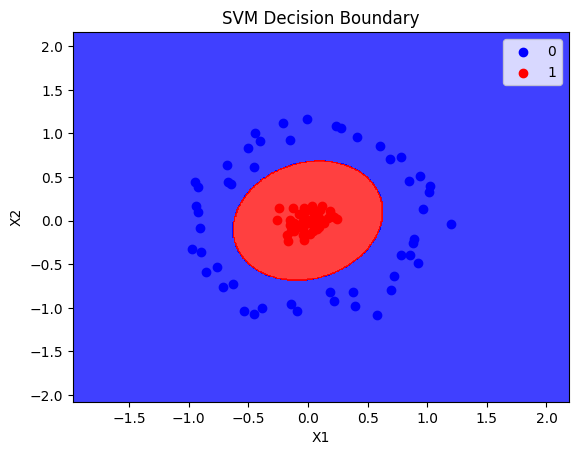

In [48]:
plot_decision_boundary(x, y, poly_classifier)

In [50]:

np.exp(-(x**2)).sum(1)

array([1.50133263, 1.93557571, 1.98777311, 1.99813012, 1.98744278,
       1.97973841, 1.97545024, 1.16144573, 1.98769404, 1.2529298 ,
       1.1340804 , 1.24051508, 1.18742788, 1.15057614, 1.33722619,
       1.97854458, 1.98212146, 1.9712256 , 1.39646893, 1.45612135,
       1.99911801, 1.99779623, 1.9206923 , 1.97342284, 1.97119558,
       1.95824601, 1.47882551, 1.98458288, 1.13221052, 1.97422956,
       1.28966277, 1.38974237, 1.25808073, 1.41604841, 1.1833452 ,
       1.37796858, 1.23742194, 1.32159475, 1.30226353, 1.23002299,
       1.37625547, 1.30062358, 1.21101107, 1.99052689, 1.99040272,
       1.99816883, 1.94857652, 1.98823678, 1.98934907, 1.99995025,
       1.98012697, 1.37575553, 1.97234713, 1.28851116, 1.18509331,
       1.2520731 , 1.98094805, 1.27542568, 1.22996865, 1.43200936,
       1.20437055, 1.9986968 , 1.33531449, 1.99776101, 1.96524486,
       1.94286618, 1.40852668, 1.95848423, 1.99118959, 1.98382955,
       1.40318588, 1.99151802, 1.99873322, 1.40099896, 1.09165

In [51]:

X_new=np.exp(-(x**2))

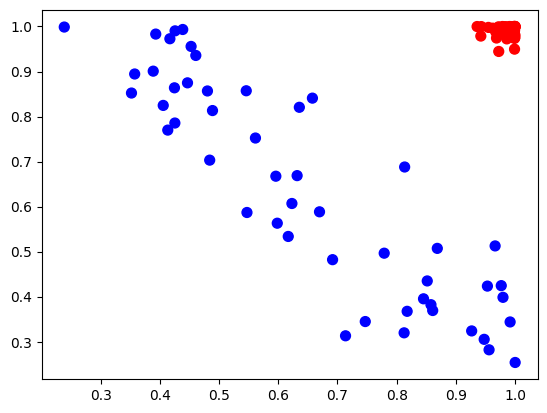

In [52]:

plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')